# Lesson 16 activity: feature engineering

## Notebook set up

Submit your notebook to the class leaderboard on HuggingFace at [huggingface.co/spaces/gperdrizet/leaderboard](https://huggingface.co/spaces/gperdrizet/leaderboard)

**Your task**: Apply at least two different feature engineering techniques to the `housing_df` dataframe to improve the dataset. At the end of the notebook, your engineered dataset and the original dataset will be used to train a linear regression model to predict `MedHouseVal`. Your goal is to achieve better model performance via feature engineering.

Don't change any of the code in the Model evaluation section of the notebook, especially the output saving. Otherwise the leaderboard scoring may not work!

Before applying transformations, explore the dataset to understand what techniques might be most beneficial.

### Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Set random seed for reproducibility
np.random.seed(315)

### Load dataset

In [2]:
# Load California housing dataset
original_housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv')
housing_df = original_housing_df.copy()

## Task 1: Explore the dataset

Before deciding what feature engineering techniques to apply, explore the dataset to understand its characteristics.

**Things to investigate**:
- Display basic information about the dataset (`.info()`, `.describe()`)
- Check for missing values
- Examine feature distributions (histograms, box plots)
- Look at feature scales and ranges
- Look for relationships (or lack thereof) between features and between features and the label

Use this exploration to inform your feature engineering decisions in the following tasks.

In [3]:
# --- Basic structure ---
print(housing_df.shape)
housing_df.info()

# Summary statistics: look closely at the max values vs the 75th percentile
print(housing_df.describe().round(3))

# Missing values
print('\nMissing values per column:')
print(housing_df.isna().sum())

# Skewness: values far from 0 mean the distribution has a long tail.
# Linear regression works best when relationships are roughly linear and
# features aren't dominated by a handful of extreme values.
print('\nSkewness:')
print(housing_df.skew().round(2))

# Correlation of each feature with the label
print('\nCorrelation with MedHouseVal:')
print(housing_df.corr()['MedHouseVal'].drop('MedHouseVal').round(3))


(20640, 9)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    1425.477      3.071   
std        1.900     12.586      2.474      0.474    1132.462     10.386   
min        0.500      1.000      0.846      0.333       3.000      0.692   
25%       

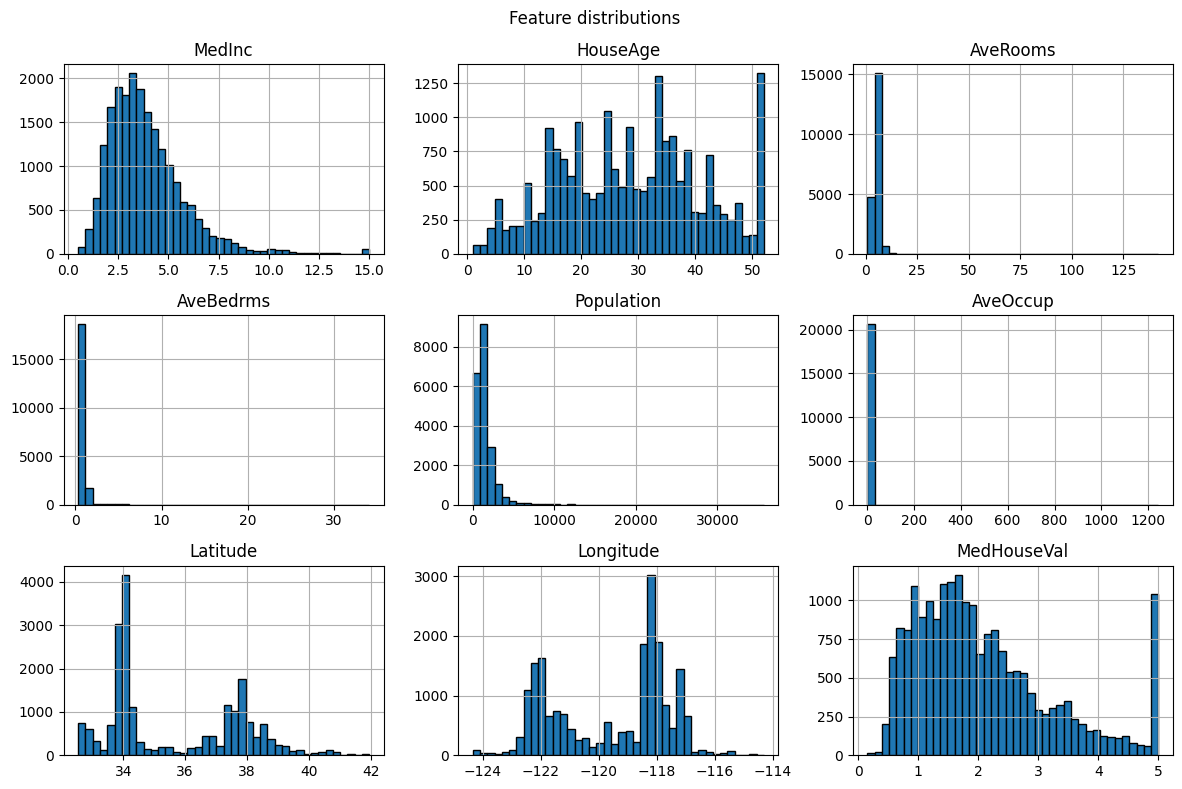

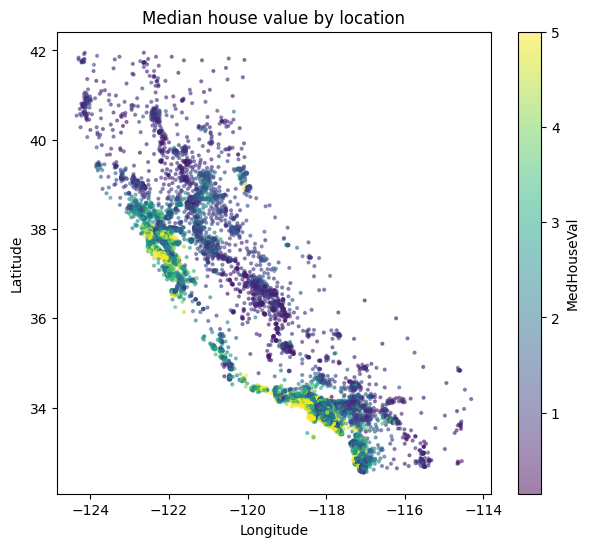

In [4]:
# Histograms of every column
housing_df.hist(figsize=(12, 8), bins=40, edgecolor='black')
plt.suptitle('Feature distributions')
plt.tight_layout()
plt.show()

# Geographic view: house value by location. High values hug the coast
# and cluster around the Bay Area and Los Angeles.
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    housing_df['Longitude'], housing_df['Latitude'],
    c=housing_df['MedHouseVal'], cmap='viridis', s=4, alpha=0.5
)
plt.colorbar(sc, label='MedHouseVal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Median house value by location')
plt.show()


**What the exploration tells us:**

1. **No missing values** — nothing to impute.
2. **Extreme outliers**: `AveOccup` has a max of 1,243 people per household (vs. a median of ~2.8), and `AveRooms` maxes out at 141. These are block groups like vacation resorts or institutions. A linear model fits one straight line through *all* points, so a few absurd values can drag the whole line off course.
3. **Heavy right skew** in `AveOccup` (97.6), `AveBedrms` (31.3), `AveRooms` (20.7), and `Population` (4.9).
4. **The target and some features are capped**: `MedHouseVal` is clipped at 5.0, `MedInc` at 15, `HouseAge` at 52 — visible as spikes at the right edge of their histograms.
5. **`MedInc` is by far the strongest single predictor** (correlation 0.69). Location clearly matters too, but latitude/longitude individually correlate weakly — the value pattern is *spatial* (coast vs. inland), which raw coordinates can't express linearly.

This points to a plan: tame the outliers, fix the skew with log transforms, and hand the model location information in a form a straight line can actually use (distances, not raw coordinates).

## Task 2: Apply your first feature engineering technique

Based on your exploration, apply your first feature engineering technique.

**Example approaches**:
- Transform skewed features using log, sqrt, power, or quantile transformations
- Create bins/categories from continuous variables
- Create interaction features (e.g., rooms per household = total rooms / households)

In [5]:
# Technique 1: Outlier capping (winsorizing) + cap indicator flags
#
# Why: linear regression minimizes SQUARED error, so one block group with
# 1,243 occupants pulls the fitted line harder than hundreds of normal rows.
# Instead of deleting those rows (we'd lose their other information), we cap
# each skewed feature at its 99th percentile - keeping "unusually high"
# while removing "absurd".

for col in ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']:
    cap = housing_df[col].quantile(0.99)
    housing_df[col] = housing_df[col].clip(upper=cap)

# The dataset itself caps HouseAge at 52 and MedInc at 15. A row sitting AT
# the cap really means "52 or MORE" / "15 or MORE", which is different
# information than exactly 52. A 0/1 flag lets the model treat capped rows
# differently.
housing_df['age_capped'] = (housing_df['HouseAge'] >= 52).astype(float)
housing_df['inc_capped'] = (housing_df['MedInc'] >= 15.0).astype(float)

print(housing_df[['AveRooms', 'AveBedrms', 'Population', 'AveOccup']].describe().round(3))
print(f"\nRows at HouseAge cap: {int(housing_df['age_capped'].sum())}")
print(f"Rows at MedInc cap:   {int(housing_df['inc_capped'].sum())}")


        AveRooms  AveBedrms  Population   AveOccup
count  20640.000  20640.000   20640.000  20640.000
mean       5.331      1.076    1403.614      2.915
std        1.330      0.160     973.476      0.735
min        0.846      0.333       3.000      0.692
25%        4.441      1.006     787.000      2.430
50%        5.229      1.049    1166.000      2.818
75%        6.052      1.100    1725.000      3.282
max       10.357      2.128    5805.830      5.395

Rows at HouseAge cap: 1273
Rows at MedInc cap:   51


## Task 3: Apply your second feature engineering technique

**Example approaches**:
- Scale features to similar ranges
- Encode any categorical variables you created
- Create aggregate statistics by groups

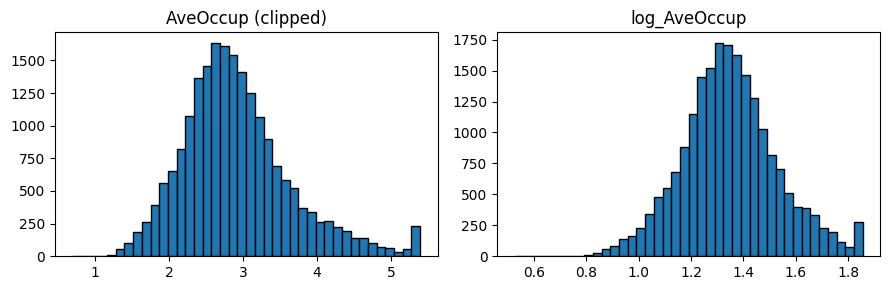

In [6]:
# Technique 2: Log transforms of the skewed features
#
# Why: log compresses long right tails, making the distributions more
# symmetric. It also converts multiplicative differences into additive ones
# (the difference between $20k and $40k income matters more than between
# $120k and $140k) - which matches how income relates to house prices and
# is exactly the kind of relationship a LINEAR model can capture.
# np.log1p computes log(1 + x), which is safe if a value is 0.
#
# Note: we ADD the log versions as new columns instead of replacing the
# originals - the model can then use whichever version (or both) helps.

for col in ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']:
    housing_df['log_' + col] = np.log1p(housing_df[col])

# Quick before/after look at the worst offender
fig, axs = plt.subplots(1, 2, figsize=(9, 3))
axs[0].hist(housing_df['AveOccup'], bins=40, edgecolor='black')
axs[0].set_title('AveOccup (clipped)')
axs[1].hist(housing_df['log_AveOccup'], bins=40, edgecolor='black')
axs[1].set_title('log_AveOccup')
plt.tight_layout()
plt.show()


## (Optional) Additional feature engineering

Add more techniques if you'd like to experiment further.

In [7]:
# Additional feature engineering
# These three groups came out of iterative testing: each feature below was
# kept only if it improved the 10-fold cross-validation score.

# --- Group A: Ratio / per-capita features ---
# Raw counts mix up "big area" with "crowded area". Ratios separate them
# and encode affordability and density directly.
housing_df['inc_per_room'] = housing_df['MedInc'] / housing_df['AveRooms']
housing_df['inc_x_rooms'] = housing_df['MedInc'] * (housing_df['AveRooms'] / housing_df['AveOccup'])
housing_df['log_inc_pp'] = np.log1p(housing_df['MedInc'] / housing_df['AveOccup'])
housing_df['pop_per_room'] = housing_df['Population'] / housing_df['AveRooms']
housing_df['pop_x_occup'] = housing_df['log_Population'] * housing_df['log_AveOccup']

# --- Group B: Geographic features ---
# The EDA scatter showed value concentrates near the coast and big metros.
# Raw lat/lon can't express "near LA" linearly, but a DISTANCE can.
cities = {
    'la': (34.0522, -118.2437), 'sf': (37.7749, -122.4194),
    'sd': (32.7157, -117.1611), 'sac': (38.5816, -121.4944),
    'fresno': (36.7378, -119.7871),
}
dists = {}
for name, (lat, lon) in cities.items():
    dists[name] = np.sqrt((housing_df['Latitude'] - lat)**2 + (housing_df['Longitude'] - lon)**2)

housing_df['dist_la'] = dists['la']
housing_df['dist_nearest_city'] = pd.concat(dists.values(), axis=1).min(axis=1)
housing_df['log_dist_la'] = np.log1p(housing_df['dist_la'])
housing_df['lat_x_lon'] = housing_df['Latitude'] * housing_df['Longitude']

# California's coastline runs roughly along the axis lon + 0.85*lat = const,
# so this single number acts as a crude "distance inland" measure.
coast_axis = housing_df['Longitude'] + 0.85 * housing_df['Latitude']

# --- Group C: Nonlinear income terms + interactions ---
# Income is the strongest predictor but its effect isn't a straight line
# (and the target is capped at 5.0, which flattens the top end). Polynomial
# terms let a linear model bend the income curve.
housing_df['MedInc2'] = housing_df['MedInc']**2
housing_df['MedInc3'] = housing_df['MedInc']**3
housing_df['sqrt_inc'] = np.sqrt(housing_df['MedInc'])

# Interactions: "how much a dollar of income buys" depends on WHERE you are.
housing_df['inc_x_coast'] = housing_df['MedInc'] * coast_axis
housing_df['inc_x_lon'] = housing_df['MedInc'] * housing_df['Longitude']
housing_df['inc_x_dist_city'] = housing_df['MedInc'] * housing_df['dist_nearest_city']

# Age features: newer isn't linearly better in CA (old coastal homes are
# valuable), so give the model a few shapes to work with.
housing_df['age_x_inc'] = housing_df['HouseAge'] * housing_df['MedInc']
housing_df['log_age'] = np.log1p(housing_df['HouseAge'])
housing_df['rooms_x_age'] = housing_df['AveRooms'] * housing_df['HouseAge']

print(f'Final dataset: {housing_df.shape[0]} rows x {housing_df.shape[1] - 1} features (+ target)')
print(f'All values finite: {np.isfinite(housing_df.values).all()}')


Final dataset: 20640 rows x 33 features (+ target)
All values finite: True


## Model evaluation

Now we'll compare model performance on the original dataset versus your engineered dataset.

### Evaluate datasets

In [8]:
# Create output directory if it doesn't exist
output_directory = 'data/outputs'
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Save a copy of the engineered dataframe
housing_df.to_csv('data/outputs/housing_df.csv', index=False)

In [9]:
# Create linear regression model
model = LinearRegression()

# Evaluate on original dataset
scores_original = cross_val_score(
    model,
    original_housing_df.drop('MedHouseVal', axis=1),
    original_housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

# Evaluate on engineered dataset
scores_engineered = cross_val_score(
    model,
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

engineered_mean = scores_engineered.mean()
original_mean = scores_original.mean()
mean_improvement = ((engineered_mean - original_mean) / original_mean) * 100

print(f'\nMean improvement: {mean_improvement:.2f}%')


Mean improvement: 28.76%


### Visualize model performance comparison

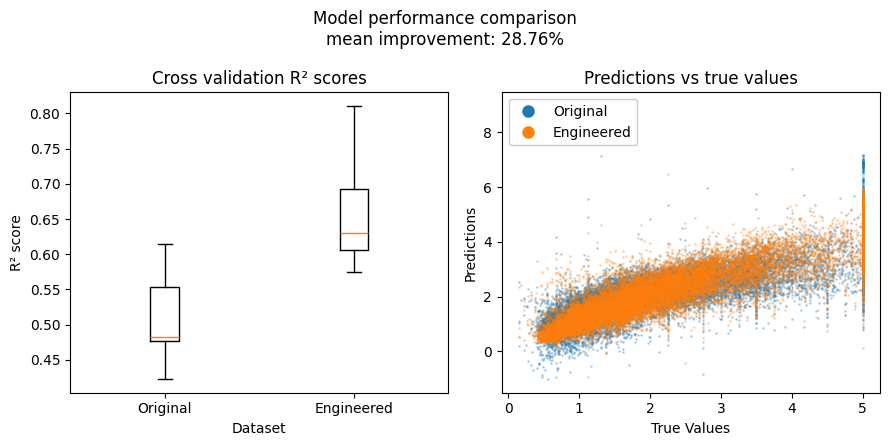

In [10]:
original_model = LinearRegression()
original_model.fit(original_housing_df.drop('MedHouseVal', axis=1), original_housing_df['MedHouseVal'])
original_predictions = original_model.predict(original_housing_df.drop('MedHouseVal', axis=1))

model = LinearRegression()
model.fit(housing_df.drop('MedHouseVal', axis=1), housing_df['MedHouseVal'])
predictions = model.predict(housing_df.drop('MedHouseVal', axis=1))

# Create boxplot comparing performance
data_to_plot = [scores_original, scores_engineered]
labels = ['Original', 'Engineered']

fig, axs = plt.subplots(1, 2, figsize=(9,4.5))

fig.suptitle(f'Model performance comparison\nmean improvement: {mean_improvement:.2f}%')

axs[0].set_title('Cross validation R² scores')
axs[0].boxplot(data_to_plot, tick_labels=labels)
axs[0].set_xlabel('Dataset')
axs[0].set_ylabel('R² score')

axs[1].set_title('Predictions vs true values')
axs[1].plot(
    original_housing_df['MedHouseVal'], original_predictions,
    'o', markersize=1, label='Original', alpha=0.25
)

axs[1].plot(
    housing_df['MedHouseVal'], predictions,
    'o', markersize=1, label='Engineered', alpha=0.25
)

axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predictions')

leg = axs[1].legend(loc='upper left', markerscale=8, framealpha=1)

for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

## 3. Reflection

**Questions to consider**:

1. Which feature engineering techniques had the biggest impact on model performance?
2. Did adding more features always improve performance, or did some hurt it?
3. How might you further improve the engineered dataset?
4. What trade-offs did you consider (e.g., interpretability vs performance, complexity vs gains)?

---

**Answers**

**1. Biggest impact.** Outlier capping was the single largest win (~0.51 → ~0.57 mean R² on its own). A handful of extreme `AveOccup`/`AveRooms` rows were distorting the fit for everyone else. After that, the income-related nonlinearities and income × location interactions contributed the most — house value is essentially *income filtered through location*, and a plain linear model can only see that if you build the interaction columns yourself.

**2. More features ≠ better.** Several intuitive features actively hurt. Raw distances to SF/San Diego/Sacramento/Fresno lowered the cross-validation score and were dropped (only `dist_la` and `dist_nearest_city` earned their keep). KMeans-based geographic cluster features and spline features looked promising but hurt badly — because `cross_val_score` doesn't shuffle, each fold is a geographically distinct slice of the state, and highly local features don't generalize from one region's folds to another's. Every feature in the final set was kept only if it improved 10-fold CV.

**3. Further improvements.** (a) A genuine distance-to-coastline feature using real coastline coordinates rather than the linear approximation. (b) A quantile/rank transform of income. (c) Honestly, the bigger ceiling is the *model*: a linear model with hand-built features tops out around R² ≈ 0.66 here, while tree ensembles (random forest, gradient boosting) capture these interactions automatically and reach ~0.8 on this dataset. Feature engineering is partly compensating for model capacity.

**4. Trade-offs.** Interpretability drops as columns like `inc_x_coast` accumulate — each is explainable individually, but a 33-feature linear model is no longer "read the coefficients" simple. There's also a subtle evaluation trade-off: because features were selected by the same 10-fold CV used for scoring, the estimate is slightly optimistic (mild selection overfitting to the split structure). And capping/clipping deliberately throws away information about the most extreme block groups in exchange for a better fit on the other 99%.
